In [3]:
import numpy as np
import healpy
import healpy as hp
import pymaster as nmt
import pysm3
import pysm3.units as u
import matplotlib.pyplot as plt
from tqdm import trange

In [12]:
complexity = 'baseline' # 'baseline', 'medium_complexity' or 'high_complexity'
tracer = 'P' # 'P', 'B' or 'P_B'
fwhm = 0
fsky = 0.5
scale = 5
apotype = 'Gaussian'

In [5]:
def masks(QU_template_for_mask,
          tracer = 'P', # 'P', 'B' or 'P_B'
          final_fsky = 85, 
          smooth_tracer_deg = 2, 
          apo_mask_deg = 2, 
          apo_type = 'C2', # NaMaster apodization type. If 'Gaussian', apodize with a Gaussian beam of fwhm given by apo_mask_deg.
          return_intermediate = False):

    if tracer == 'P':
        if smooth_tracer_deg!=0: 
            QU_template_for_mask_sm = healpy.sphtfunc.smoothing([0*QU_template_for_mask[0], 
                                                           QU_template_for_mask[0], 
                                                           QU_template_for_mask[1]], 
                                                           fwhm=np.radians(smooth_tracer_deg))
            
        else: QU_template_for_mask_sm = np.array([0*QU_template_for_mask[0],
                                                  QU_template_for_mask[0],
                                                  QU_template_for_mask[1]])

        template_for_mask_sm = np.sqrt(QU_template_for_mask_sm[1]**2+QU_template_for_mask_sm[2]**2)        

    elif tracer == 'B':         
        template_for_mask = np.abs(hp.alm2map(hp.map2alm([0*QU_template_for_mask[0],
                                                  QU_template_for_mask[0],
                                                  QU_template_for_mask[1]])[2], nside=hp.npix2nside(len(QU_template_for_mask[0])))
                                  )
        if smooth_tracer_deg!=0: 
            template_for_mask_sm = healpy.sphtfunc.smoothing(template_for_mask,
                                                           fwhm=np.radians(smooth_tracer_deg))
        else: template_for_mask_sm = template_for_mask
        
    elif tracer == 'P_B':     
        alm_B = hp.map2alm([0*QU_template_for_mask[0],
                            QU_template_for_mask[0],
                            QU_template_for_mask[1]])[2]
        QBUB_template_for_mask = hp.alm2map([alm_B, 0*alm_B, alm_B], nside=hp.npix2nside(len(QU_template_for_mask[0])))
        template_for_mask= np.sqrt(QBUB_template_for_mask[1]**2+QBUB_template_for_mask[2]**2)

        if smooth_tracer_deg!=0: 
            template_for_mask_sm = healpy.sphtfunc.smoothing(template_for_mask,
                                                           fwhm=np.radians(smooth_tracer_deg))
        else: template_for_mask_sm = template_for_mask
    
    N = int((1-final_fsky/100)*len(template_for_mask_sm))
    mask_raw = np.array(len(template_for_mask_sm)*[1])
    for i in np.argsort(np.abs(template_for_mask_sm))[-N:]:
        mask_raw[i] = 0
    
    if apo_mask_deg!=0:
        if apo_type == 'Gaussian':
            apo_mask = hp.smoothing(mask_raw, fwhm=np.radians(apo_mask_deg))
            apo_mask[apo_mask < 1e-5], apo_mask[apo_mask > 1] = 0, 1
        else:
            apo_mask = nmt.mask_apodization(mask_raw, aposize=apo_mask_deg, apotype=apo_type)
    else:
        apo_mask = mask_raw
    
    if return_intermediate: return apo_mask, mask_raw, template_for_mask_sm
    return apo_mask

In [6]:
path_mbs = f'/pscratch/sd/s/svinzl/B_modes_project/maps/maps_downgraded_nside64_e2e_{complexity}.npy'
QU_template = np.load(path_mbs)[0,0,-1]

fsky of apodized mask: 0.4239045880421717


"\nif apotype == 'Gaussian':\n    hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_402_{fwhm}deg_{complexity}_nside64_aposcale{scale}_gauss.npy', apo_mask)\nelse:\n    hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_402_{fwhm}deg_{complexity}_nside64_aposcale{scale}.npy', apo_mask)\n"

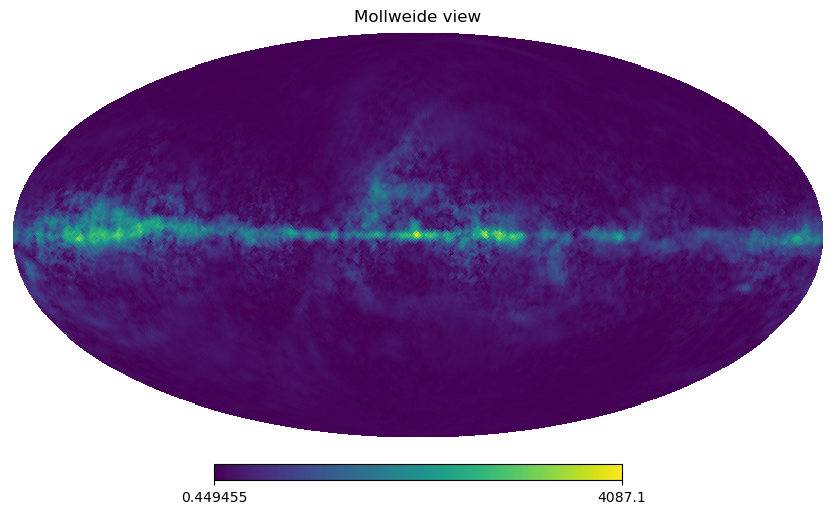

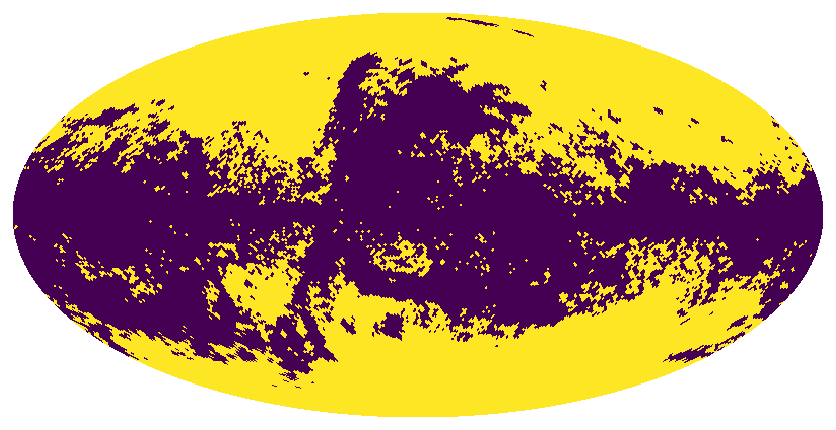

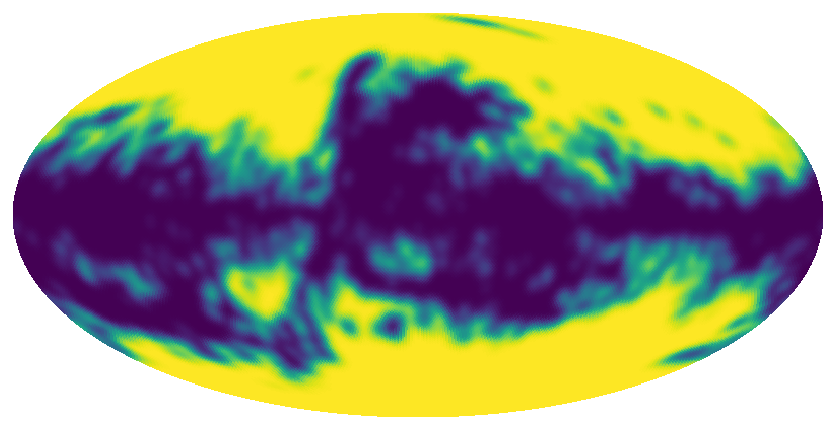

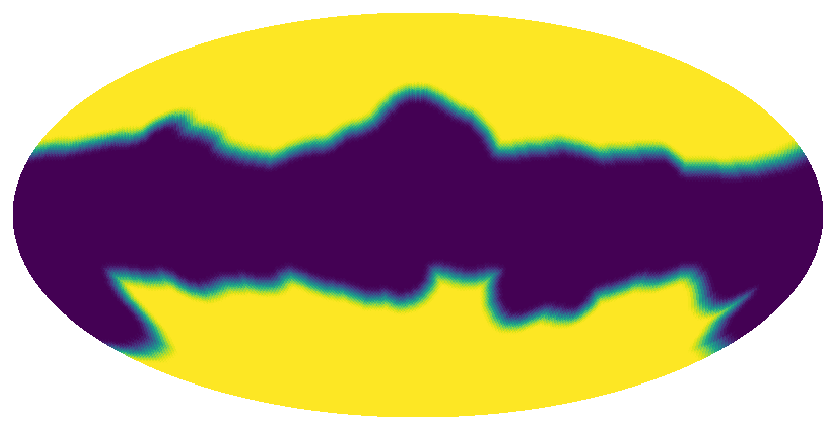

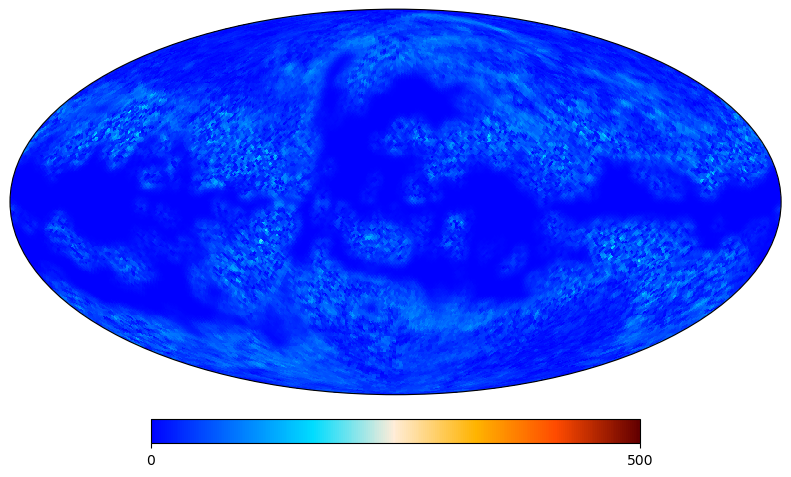

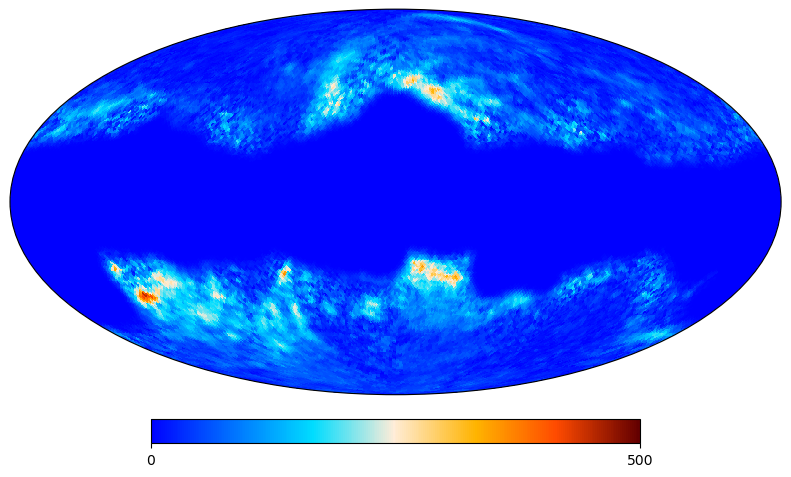

In [14]:
apo_mask, mask_raw, template_for_mask_sm = masks(QU_template,
          tracer = tracer,
          final_fsky = fsky*100, 
          smooth_tracer_deg = fwhm, 
          apo_mask_deg = scale, 
          apo_type = apotype,
          return_intermediate = True)

mask_planck = hp.read_map(f'../masks/mask_fsky{0.6}_nside64_aposcale10.npy')

hp.mollview(template_for_mask_sm)
hp.mollview(mask_raw, title=None, cbar=False)
hp.mollview(apo_mask, title=None, cbar=False)
hp.mollview(mask_planck, title=None, cbar=False)
hp.projview(apo_mask * np.sqrt(np.sum(QU_template**2, axis=0)), cmap='planck', min=0, max=500)
hp.projview(mask_planck * np.sqrt(np.sum(QU_template**2, axis=0)), cmap='planck', min=0, max=500)

fsky_eff = np.mean(apo_mask**2)
print(f'fsky of apodized mask: {fsky_eff}')

"""
if apotype == 'Gaussian':
    hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_402_{fwhm}deg_{complexity}_nside64_aposcale{scale}_gauss.npy', apo_mask)
else:
    hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_402_{fwhm}deg_{complexity}_nside64_aposcale{scale}.npy', apo_mask)
"""

In [7]:
# FGBuster mask

if complexity == 'medium_complexity':
    complexity = 'medium'
elif complexity == 'high_complexity':
    complexity = 'high'

path_fgbuster = f'/global/cfs/cdirs/litebird/results/b_modes_postptep/cs_products/fgbuster/{complexity}/comp_sep_res/result_0000_CorrectSmoothTrue_ns64_reso80arcmin_CorrectBandpassTrue_Nsample20_fullsky_adapt_multires_Bd_64_64_64_Td_8_4_0_Bs_4_2_2_HEALPIX_patches.npz'
archive = np.load(path_fgbuster, allow_pickle=True)
QU_dust, QU_sync = archive['res'].item()['s'][1:]

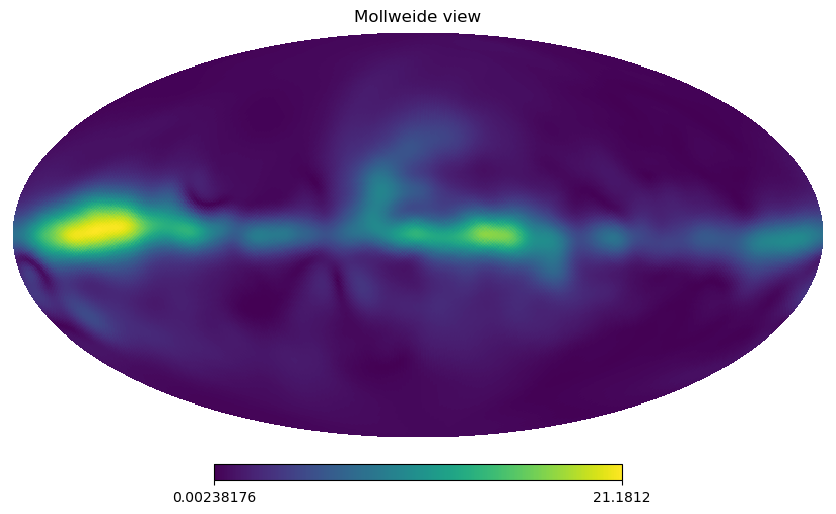

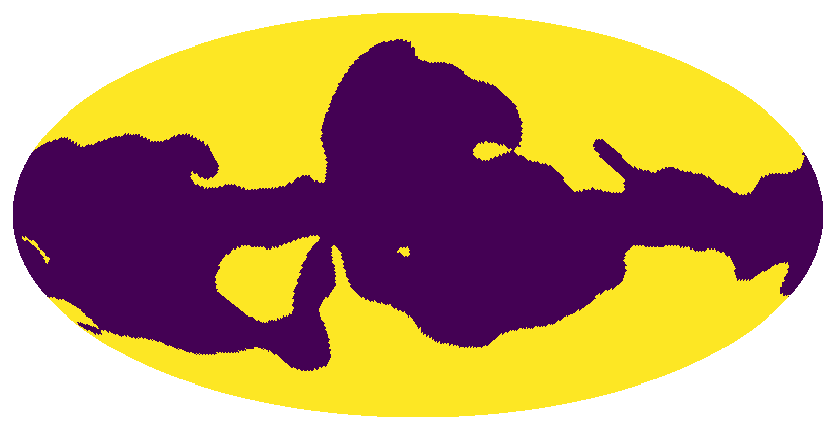

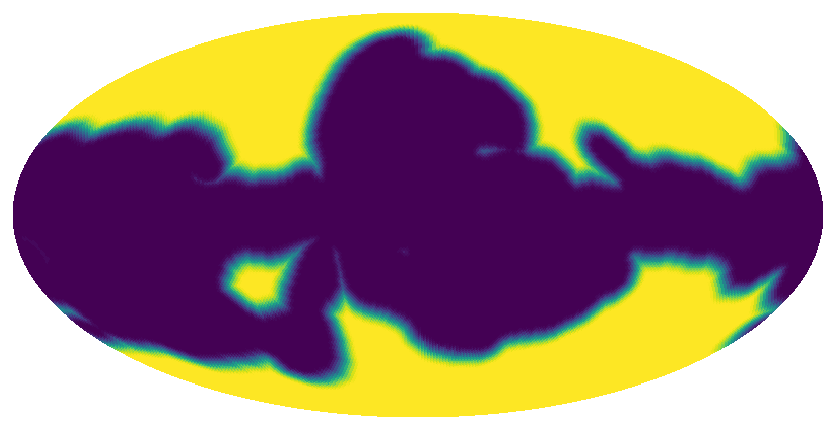

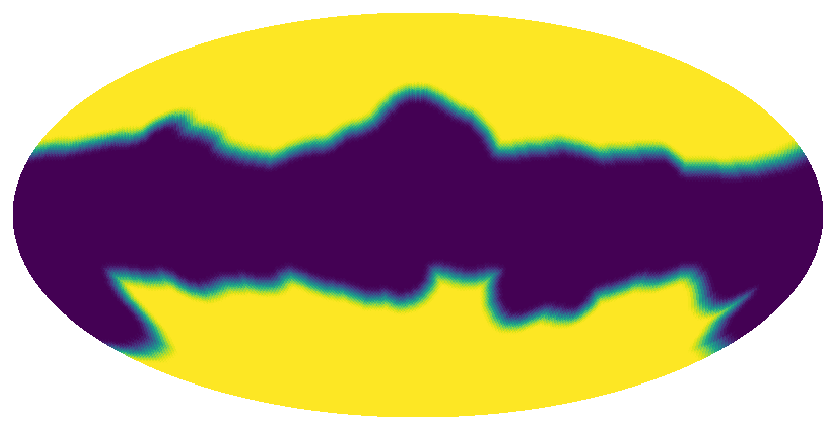

In [8]:
QU_template = QU_dust + QU_sync

apo_mask, mask_raw, template_for_mask_sm = masks(QU_template,
          tracer = tracer,
          final_fsky = fsky*100, 
          smooth_tracer_deg = fwhm, 
          apo_mask_deg = scale, 
          eps=1e-5,
          return_intermediate = True)

hp.mollview(template_for_mask_sm)
hp.mollview(mask_raw, title=None, cbar=False)
hp.mollview(apo_mask, title=None, cbar=False)
hp.mollview(mask_planck, title=None, cbar=False)

#hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_fgbuster_dustsync_{fwhm}deg_{complexity}_nside64_aposcale{scale}.npy', apo_mask, overwrite=True)

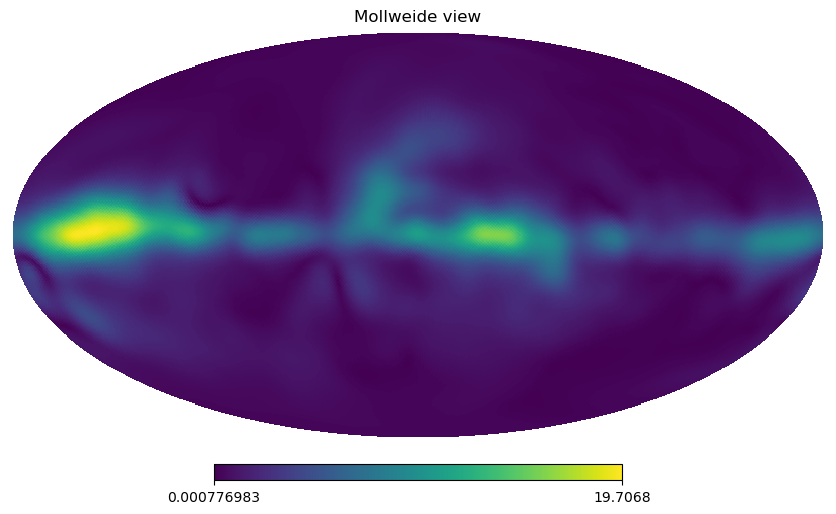

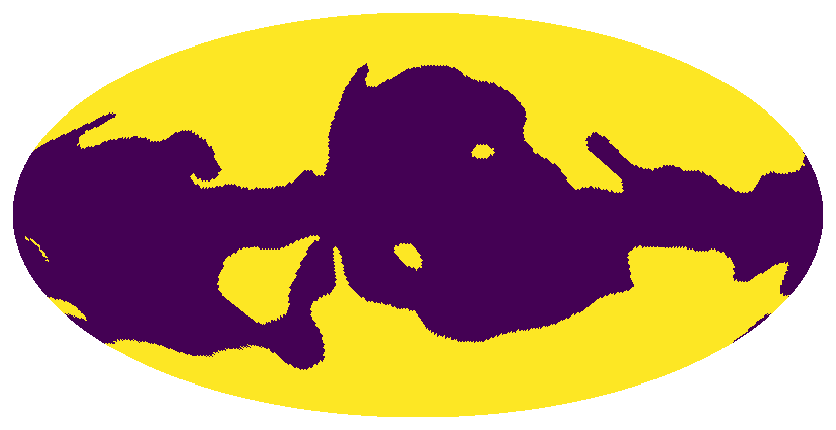

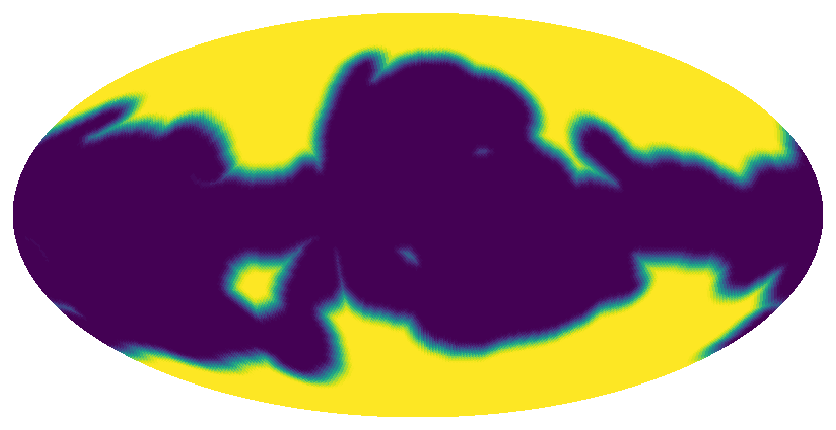

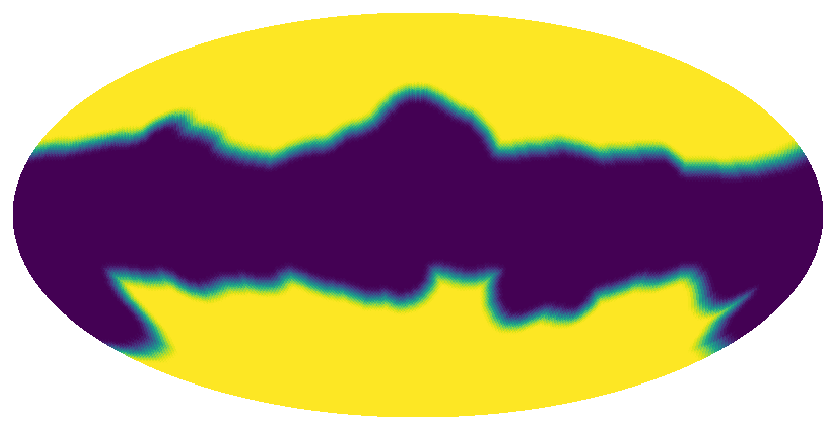

In [9]:
QU_template = QU_dust

apo_mask, mask_raw, template_for_mask_sm = masks(QU_template,
          tracer = 'P',
          final_fsky = fsky*100, 
          smooth_tracer_deg = fwhm, 
          apo_mask_deg = scale, 
          eps=1e-5,
          return_intermediate = True)

hp.mollview(template_for_mask_sm)
hp.mollview(mask_raw, title=None, cbar=False)
hp.mollview(apo_mask, title=None, cbar=False)
hp.mollview(mask_planck, title=None, cbar=False)

#hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_fgbuster_dust_{fwhm}deg_{complexity}_nside64_aposcale{scale}.npy', apo_mask, overwrite=True)

In [10]:
# GNILC mask

path_gnilc = f'/global/cfs/cdirs/litebird/results/b_modes_postptep/gnilc_maps_v1/{complexity}/output_total/00000/QU_output_total_LB_HFT_H3-402_70.5acm_ns64_lmax191_00000.fits'
QU_402 = hp.read_map(path_gnilc, field=None)

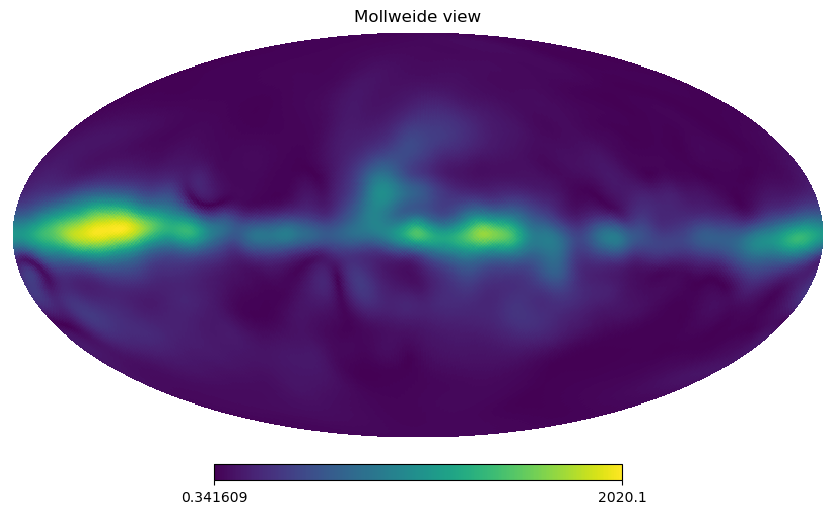

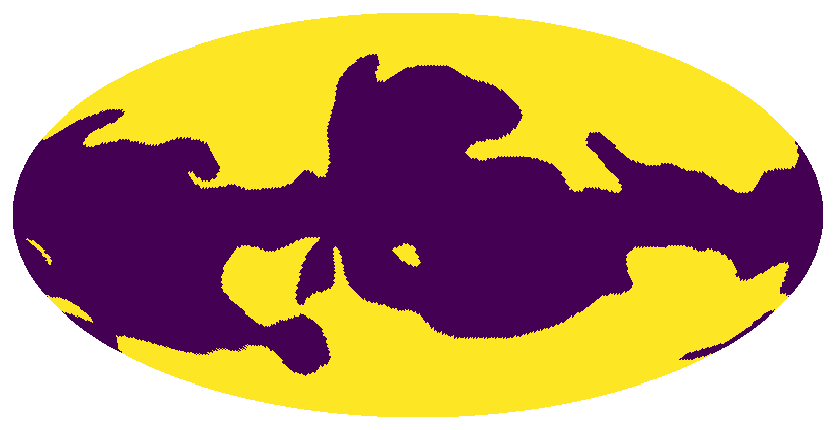

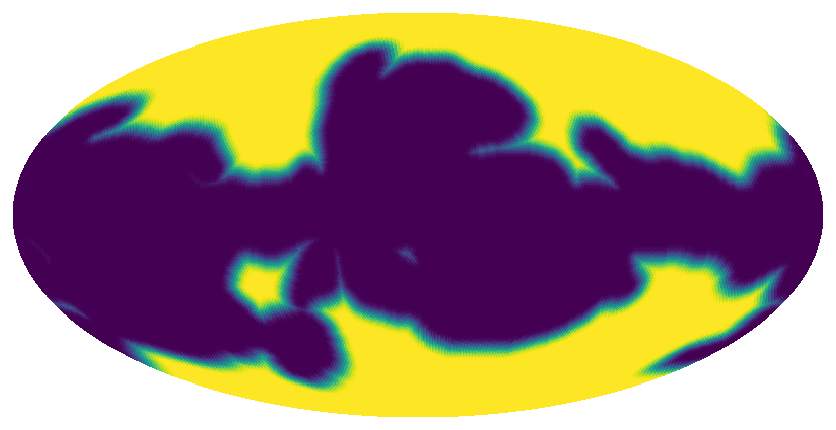

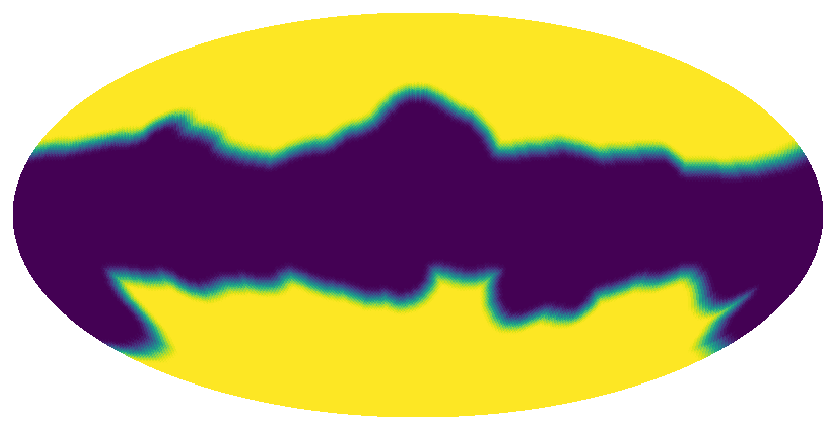

In [11]:
QU_template = QU_402

apo_mask, mask_raw, template_for_mask_sm = masks(QU_template,
          tracer = 'P',
          final_fsky = fsky*100, 
          smooth_tracer_deg = fwhm, 
          apo_mask_deg = scale, 
          eps=1e-5,
          return_intermediate = True)

hp.mollview(template_for_mask_sm)
hp.mollview(mask_raw, title=None, cbar=False)
hp.mollview(apo_mask, title=None, cbar=False)
hp.mollview(mask_planck, title=None, cbar=False)

#hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_gnilc_402_{fwhm}deg_{complexity}_nside64_aposcale{scale}.npy', apo_mask, overwrite=True)

In [259]:
np.mean(apo_mask**2), np.mean(mask_planck**2)

(np.float64(0.3538081608075602), np.float64(0.49473447126200093))

In [260]:
# Test on CMB only

N = 100
nside = 64
lmax = 2*nside-1
Nlbin = 10

b = nmt.NmtBin.from_lmax_linear(lmax, nlb=Nlbin, is_Dell=True)
leff = b.get_effective_ells()
Nbins = len(leff)

Cl_CMB = hp.read_cl('../power_spectra/Cls_LiteBIRD_e2e_r0.fits')
Dl_BB = np.zeros((N, Nbins))

f = nmt.NmtField(apo_mask, None, spin=2, lmax=lmax, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

for i in trange(N):
    cmb = hp.synfast(Cl_CMB, nside, new=True)[1:]

    f = nmt.NmtField(apo_mask, cmb, purify_b=True)
    Cl_coupled = nmt.compute_coupled_cell(f, f)
    Dl_BB[i] = w.decouple_cell(Cl_coupled)[3]

Dl_CMB_GWD = w.decouple_cell(w.couple_cell([Cl_CMB[1], 0*Cl_CMB[0], 0*Cl_CMB[0], Cl_CMB[2]]))[3]

100%|██████████| 100/100 [00:12<00:00,  8.16it/s]


In [261]:
# Planck 60% on CMB only

f = nmt.NmtField(mask_planck, None, spin=2, lmax=lmax, purify_b=True)
w = nmt.NmtWorkspace()
w.compute_coupling_matrix(f, f, b)

Dl_BB_planck = np.zeros((N, Nbins))

for i in trange(N):
    cmb = hp.synfast(Cl_CMB, nside, new=True)[1:]

    f = nmt.NmtField(mask_planck, cmb, purify_b=True)
    Cl_coupled = nmt.compute_coupled_cell(f, f)
    Dl_BB_planck[i] = w.decouple_cell(Cl_coupled)[3]

Dl_CMB_planck = w.decouple_cell(w.couple_cell([Cl_CMB[1], 0*Cl_CMB[0], 0*Cl_CMB[0], Cl_CMB[2]]))[3]

100%|██████████| 100/100 [00:11<00:00,  8.40it/s]


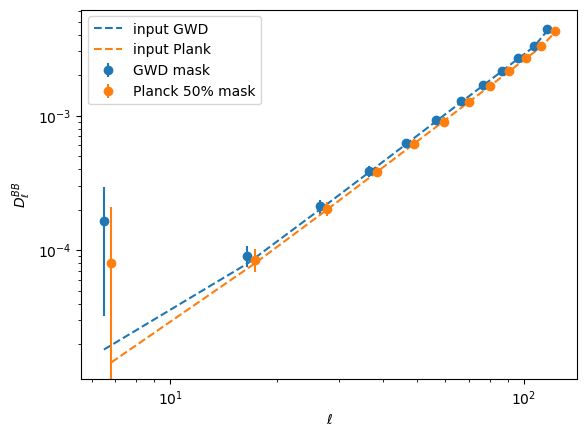

In [262]:
plt.plot(leff, Dl_CMB_GWD, '--', label='input GWD', color='C0')
plt.errorbar(leff, np.mean(Dl_BB, axis=0), yerr=np.std(Dl_BB, axis=0), fmt='o', label='GWD mask', color='C0')
plt.plot(leff*1.05, Dl_CMB_planck, '--', label='input Plank', color='C1')
plt.errorbar(leff*1.05, np.mean(Dl_BB_planck, axis=0), yerr=np.std(Dl_BB, axis=0), fmt='o', label=f'Planck {int(fsky*100)}% mask', color='C1')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{BB}$')
plt.legend()

In [224]:
if complexity == 'medium_complexity':
    complexity = 'medium'
elif complexity == 'high_complexity':
    complexity = 'high'

#hp.write_map(f'/pscratch/sd/s/svinzl/B_modes_project/masks/mask_fsky{fsky}_{tracer}_402_{fwhm}deg_{complexity}_nside64_aposcale{scale}.npy', apo_mask)